## **MRMS RadarOnly QPE**

### **Imports**

In [1]:

from pathlib import Path
import random, numpy as np, matplotlib.pyplot as plt
import pandas as pd, geopandas as gpd
from datetime import datetime, timedelta
import gzip
import shutil

import boto3
from botocore import UNSIGNED
from botocore.config import Config

import xarray as xr


In [2]:
random.seed(14912)

### **Paths**

In [3]:

root_path = Path.cwd()
compress_path = root_path / 'data/samples/compress_path'
extraction_path = root_path / 'data/samples/extracted_files'

temporal_compress_path = root_path / "data/samples/temporal_compress"
temporal_extraction_path = root_path / "data/samples/temporal_extracted"

compress_path.mkdir(parents=True, exist_ok=True)
extraction_path.mkdir(parents=True, exist_ok=True)
temporal_compress_path.mkdir(parents=True, exist_ok=True)
temporal_extraction_path.mkdir(parents=True, exist_ok=True)

print(compress_path.exists(), extraction_path.exists(), temporal_compress_path.exists(), temporal_extraction_path.exists())


True True True True



### **MRMS**

The **Multi-Radar/Multi-Sensor (MRMS)** system is an operational NOAA/NWS framework that combines weather radar, environmental information, and other observations to generate high-resolution precipitation and severe-weather products.


### **RadarOnly QPE**

This is the primary product used in this project and it represents **radar-derived precipitation accumulated over the previous one-hour period**, without the gauge-bias correction applied to other MRMS gauge-adjusted QPE products.

| Property              | `RadarOnly_QPE_01H`                      |
| --------------------- | ---------------------------------------- |
| Product name          | `RadarOnly_QPE_01H`                      |
| Physical quantity     | Radar-derived precipitation accumulation |
| Accumulation period   | 1 hour                                   |
| Update interval       | 2 minutes                                |
| Units                 | mm                                       |
| Spatial resolution    | ~1 km × 1 km                             |
| Main upstream product | Surface Precipitation Rate (SPR)         |
| Gauge bias correction | No                                       |
| Format                | GRIB2                                    |
| Primary project role  | Base radar precipitation observation     |


The aim of this project is to forecast/predict the hourly corrected precipitation values and therefore we will be using `RadarOnly_QPE_01H` as one of our primary inputs. It represents a **1-hour precipitation accumulation**, but a new product is generated approximately every **2 minutes**. Therefore, consecutive files largely represent **overlapping rolling one-hour accumulation windows**.

For example:

```text id="j3gvfe"
12:00 file → precipitation accumulated approximately 11:00–12:00
12:02 file → precipitation accumulated approximately 11:02–12:02
12:04 file → precipitation accumulated approximately 11:04–12:04
```

Thus, the files should **not simply be summed** to calculate longer-duration precipitation because most of their accumulation periods overlap.




### **RadarOnly QPE Can Be Unreliable**

Radar-derived precipitation estimates can contain substantial errors even when a valid numerical precipitation value is present. Important sources of uncertainty include:

* **Beam blockage:** Terrain can partially or completely block the radar beam.
* **Radar range:** At greater distances, the radar beam samples increasingly higher elevations above the surface.
* **Precipitation microphysics:** Rain, snow, hail, and mixed precipitation produce different radar responses.
* **Ground clutter:** Terrain, buildings, and other non-meteorological objects can contaminate radar observations.
* **Anomalous propagation:** Atmospheric conditions can bend the radar beam abnormally and produce non-meteorological echoes.
* **Hail:** Strong radar reflectivity from hail can lead to substantial precipitation overestimation.
* **Attenuation:** Heavy precipitation can weaken the radar signal, potentially causing underestimation farther along the radar beam.

These limitations are particularly important because a **numerically valid RadarOnly QPE value does not necessarily imply that the estimate is equally reliable at every location or time**.


Now lets work on downloading a few files and we will inspect some of the fields such as metadata, units and value ranges etc. 

---


### **Data Download**

The 1H data are publicly available through the [**NOAA MRMS Amazon S3 archive**](https://noaa-mrms-pds.s3.amazonaws.com/index.html). It has the structure:

```text id="2x2pbb"
CONUS/
└── RadarOnly_QPE_01H_00.00/
    ├── YYYYMMDD/
    │   ├── MRMS_RadarOnly_QPE_01H_00.00_YYYYMMDD-HHMMSS.grib2.gz
    │   └── ...
```

For example:

```text id="r8bhjm"
MRMS_RadarOnly_QPE_01H_00.00_20201014-000000.grib2.gz
MRMS_RadarOnly_QPE_01H_00.00_20201014-000200.grib2.gz
MRMS_RadarOnly_QPE_01H_00.00_20201014-000400.grib2.gz
```

The timestamps increase by approximately **2 minutes**, consistent with the expected update frequency of the product. Therefore a complete would theoretically contain:

$$
\frac{24 \times 60}{2} = 720\ \text{files/day}
$$

However, not every day will have 720 files, some days will have missing files. We will verify the daily files count later once we download the complete dataset. 

At this stage, we wont be downloading complete data. We will download a small number of representative `.grib2.gz` files and inspect the data values, distribution and visual a few days data. Lets get started. 


In [4]:

# NOAA MRMS public S3 bucket
bucket = "noaa-mrms-pds"
product = "CONUS/RadarOnly_QPE_01H_00.00" # see the above structure

# we can download a random date data between October 16 to onward - 

start_date = datetime(2020, 10, 16)
end_date = datetime.today() - timedelta(days=1)

# get a random date
random_days = random.randint(0, (end_date - start_date).days)
random_date = (start_date + timedelta(days=random_days)).strftime("%Y%m%d")
random_date


'20251006'

In [5]:

# we will use boto3, no need for any credentials, anonymous access
s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

prefix = f"{product}/{random_date}/"

# lets see available files for the selected date
response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix) # one requests retrun 1000 files - means the whole day can be 
                                                            # recover with one request 

files = [obj["Key"] for obj in response.get("Contents", []) if obj["Key"].endswith(".grib2.gz")]

print(f"Number of files found: {len(files)}")

# print a few files paths and see which dates/timestamps are missing
available_times = set()
for key in files:
    filename = Path(key).name # the naming example is:  MRMS_RadarOnly_QPE_01H_00.00_20260508-000000.grib2.gz
    timestamp_str = filename.split("_")[-1].replace(".grib2.gz", "")
    available_times.add(datetime.strptime(timestamp_str, "%Y%m%d-%H%M%S"))


day_start = datetime.strptime(random_date, "%Y%m%d")

expected_times = {day_start + timedelta(minutes=2 * i) for i in range(720)}
missing_times = sorted(expected_times - available_times) # this will return the missing times

print(f"Expected files : {len(expected_times)}")
print(f"Available files: {len(available_times)}")
print(f"Missing files  : {len(missing_times)}")

for t in missing_times:
    print(t.strftime("%Y-%m-%d %H:%M:%S"))
    

Number of files found: 719
Expected files : 720
Available files: 719
Missing files  : 1
2025-10-06 23:24:00


In [6]:

# now lets download a few timestamps from the same day
sample_files = random.sample(files, 5)

for key in sample_files:
    local_path = compress_path / Path(key).name

    print(f"Downloading: {Path(key).name}")

    s3.download_file(bucket, key, str(local_path))

print("\nDownloaded files:")
for path in sorted(compress_path.glob("*.grib2.gz")):
    print(path)


Downloading: MRMS_RadarOnly_QPE_01H_00.00_20251006-135000.grib2.gz
Downloading: MRMS_RadarOnly_QPE_01H_00.00_20251006-175000.grib2.gz
Downloading: MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.grib2.gz
Downloading: MRMS_RadarOnly_QPE_01H_00.00_20251006-034200.grib2.gz
Downloading: MRMS_RadarOnly_QPE_01H_00.00_20251006-092400.grib2.gz

Downloaded files:
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_only_qpe/data/samples/compress_path/MRMS_RadarOnly_QPE_01H_00.00_20251006-034200.grib2.gz
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_only_qpe/data/samples/compress_path/MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.grib2.gz
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/radar_only_qpe/data/samples/compress_path/MRMS_RadarOnly_QPE_01H_00.00_20251006-092400.grib2.gz
/home/adil/Desktop/PhD_Research/Research_Projects/QPE_Project/dataset/data_understanding/ra

In [7]:

# lets extract the files and save in the extraction path - we will keep the raw files
for gz_path in compress_path.glob("*.grib2.gz"):
    grib_path = extraction_path / gz_path.name.replace(".gz", "")  

    if not grib_path.exists():
        with gzip.open(gz_path, "rb") as f_in:
            with open(grib_path, "wb") as f_out:
                shutil.copyfileobj(f_in, f_out)

        print(f"Created: {grib_path.name}")




Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-092400.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-034200.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-135000.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-175000.grib2


### **Metadata/Values Inspection**

We will inspect the download files to verify the product characteristics directly from the raw data. We first examine one sample file for variable information, units, temporal metadata, grid dimensions, coordinates, and GRIB attributes, and then check whether these properties remain consistent across the sampled files.


In [8]:

# lets first get the extracted grib files
grib_files = sorted(extraction_path.glob("*.grib2"))

# lets select a radnom file for inspection
sample_path = random.choice(grib_files)

# we will use xarray to open the dataset
ds = xr.open_dataset(sample_path, engine='cfgrib')

ds # print(ds) does not provide complete details - just my observation, not the facto


<xarray.Dataset> Size: 98MB
Dimensions:         (latitude: 3500, longitude: 7000)
Coordinates:
    time            datetime64[ns] 8B ...
    step            timedelta64[ns] 8B ...
    heightAboveSea  float64 8B ...
  * latitude        (latitude) float64 28kB 54.99 54.98 54.98 ... 20.02 20.01
  * longitude       (longitude) float64 56kB 230.0 230.0 230.0 ... 300.0 300.0
    valid_time      datetime64[ns] 8B ...
Data variables:
    unknown         (latitude, longitude) float32 98MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             161
    GRIB_centreDescription:  US NOAA Office of Oceanic and Atmospheric Research
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US NOAA Office of Oceanic and Atmospheric Research
    history:                 2026-08-26T15:28 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:

# inspect the metadata/values
print("File:", sample_path.name)
print("\nDimensions:")
print(ds.sizes)

print("\nCoordinates:")
print(list(ds.coords))

print("\nData variables:")
print(list(ds.data_vars))

print("\nDataset attributes:")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")


File: MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.grib2

Dimensions:
Frozen({'latitude': 3500, 'longitude': 7000})

Coordinates:
['time', 'step', 'heightAboveSea', 'latitude', 'longitude', 'valid_time']

Data variables:
['unknown']

Dataset attributes:
GRIB_edition: 2
GRIB_centre: 161
GRIB_centreDescription: US NOAA Office of Oceanic and Atmospheric Research
GRIB_subCentre: 0
Conventions: CF-1.7
institution: US NOAA Office of Oceanic and Atmospheric Research
history: 2026-08-26T15:28 GRIB to CDM+CF via cfgrib-0.9.15.1/ecCodes-2.47.0 with {"source": "data/samples/extracted_files/MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.grib2", "filter_by_keys": {}, "encode_cf": ["parameter", "time", "geography", "vertical"]}




>Glad that we added above block, it shows something important: ['unknown'], GRIB_paramId: 0, 
GRIB_name: unknown, GRIB_units: unknown. meaning That means cfgrib/ecCodes is not recognizing the MRMS-specific GRIB parameter definition, so it cannot label the field correctly. But the actual 2-D array stored in ds["unknown"]. Lets confirm it.>



In [10]:

summary = []
for path in grib_files:

    with xr.open_dataset(path, engine="cfgrib") as ds_i:

        da = ds_i[list(ds_i.data_vars)[0]]
        values = da.values

        # valid precipitation values only
        valid = values[values >= 0]

        summary.append({
            "file": path.name,
            "shape": values.shape,
            "dtype": str(values.dtype),

            # raw values - here mean and median will be inflated since those are also including the identifiers too
            "min_raw": np.min(values),
            "max_raw": np.max(values),
            "mean_raw": np.mean(values),
            "median_raw": np.median(values),

            # special/missing values
            "nan_count": np.isnan(values).sum(),
            "negative_count": np.sum(values < 0),
            "zero_count": np.sum(values == 0),
            "positive_count": np.sum(values > 0),

            # valid precipitation values only - here we will exclude the missing values. 
            "min_valid_mm": np.min(valid),
            "max_valid_mm": np.max(valid),
            "mean_valid_mm": np.mean(valid),
            "median_valid_mm": np.median(valid),
            "p90_valid_mm": np.percentile(valid, 90),
            "p95_valid_mm": np.percentile(valid, 95),
            "p99_valid_mm": np.percentile(valid, 99),
            "wet_fraction": np.mean(valid > 0),
        })

summary_df = pd.DataFrame(summary)
summary_df.to_csv('./summary.csv', index=False)
summary_df


,file,shape,dtype,min_raw,max_raw,mean_raw,median_raw,nan_count,negative_count,zero_count,positive_count,min_valid_mm,max_valid_mm,mean_valid_mm,median_valid_mm,p90_valid_mm,p95_valid_mm,p99_valid_mm,wet_fraction
0,MRMS_RadarOnly_QPE_01H_00.00_20251006-034200.g...,"(3500, 7000)",float32,-3.0,61.799999,-1.020566,0.0,0,8603481,15402826,493693,0.0,61.799999,0.050740,0.0,0.0,0.0,1.4,0.031057
1,MRMS_RadarOnly_QPE_01H_00.00_20251006-053600.g...,"(3500, 7000)",float32,-3.0,67.599998,-1.020128,0.0,0,8603481,15380331,516188,0.0,67.599998,0.051414,0.0,0.0,0.0,1.5,0.032472
2,MRMS_RadarOnly_QPE_01H_00.00_20251006-092400.g...,"(3500, 7000)",float32,-3.0,66.199997,-1.021421,0.0,0,8603481,15318379,578140,0.0,66.199997,0.049421,0.0,0.0,0.0,1.4,0.036369
3,MRMS_RadarOnly_QPE_01H_00.00_20251006-135000.g...,"(3500, 7000)",float32,-3.0,60.400002,-1.016037,0.0,0,8603481,15194339,702180,0.0,60.400002,0.057719,0.0,0.0,0.0,1.5,0.044172
4,MRMS_RadarOnly_QPE_01H_00.00_20251006-175000.g...,"(3500, 7000)",float32,-3.0,58.099998,-1.016617,0.0,0,8603481,15160901,735618,0.0,58.099998,0.056824,0.0,0.0,0.0,1.4,0.046275


Across all five sampled files, the only negative value observed is **`-3`**. According to the official [MRMS product table](https://www.nssl.noaa.gov/projects/mrms/operational/tables.php):

- **`-3` = no radar coverage**
- **`-1` = missing value**

Therefore, these samples contain **no-radar-coverage pixels**, but no `-1` missing-value pixels. The negative values should be treated as **non-physical sentinel values and masked before computing precipitation statistics**.

Next - Lets visualize the data, we have confirmed that -3 is our no-radar coverage pixels, we can mask them out as NaN pixels. We will plot all of five maps for visual comparison.


### **Visual Inspection**

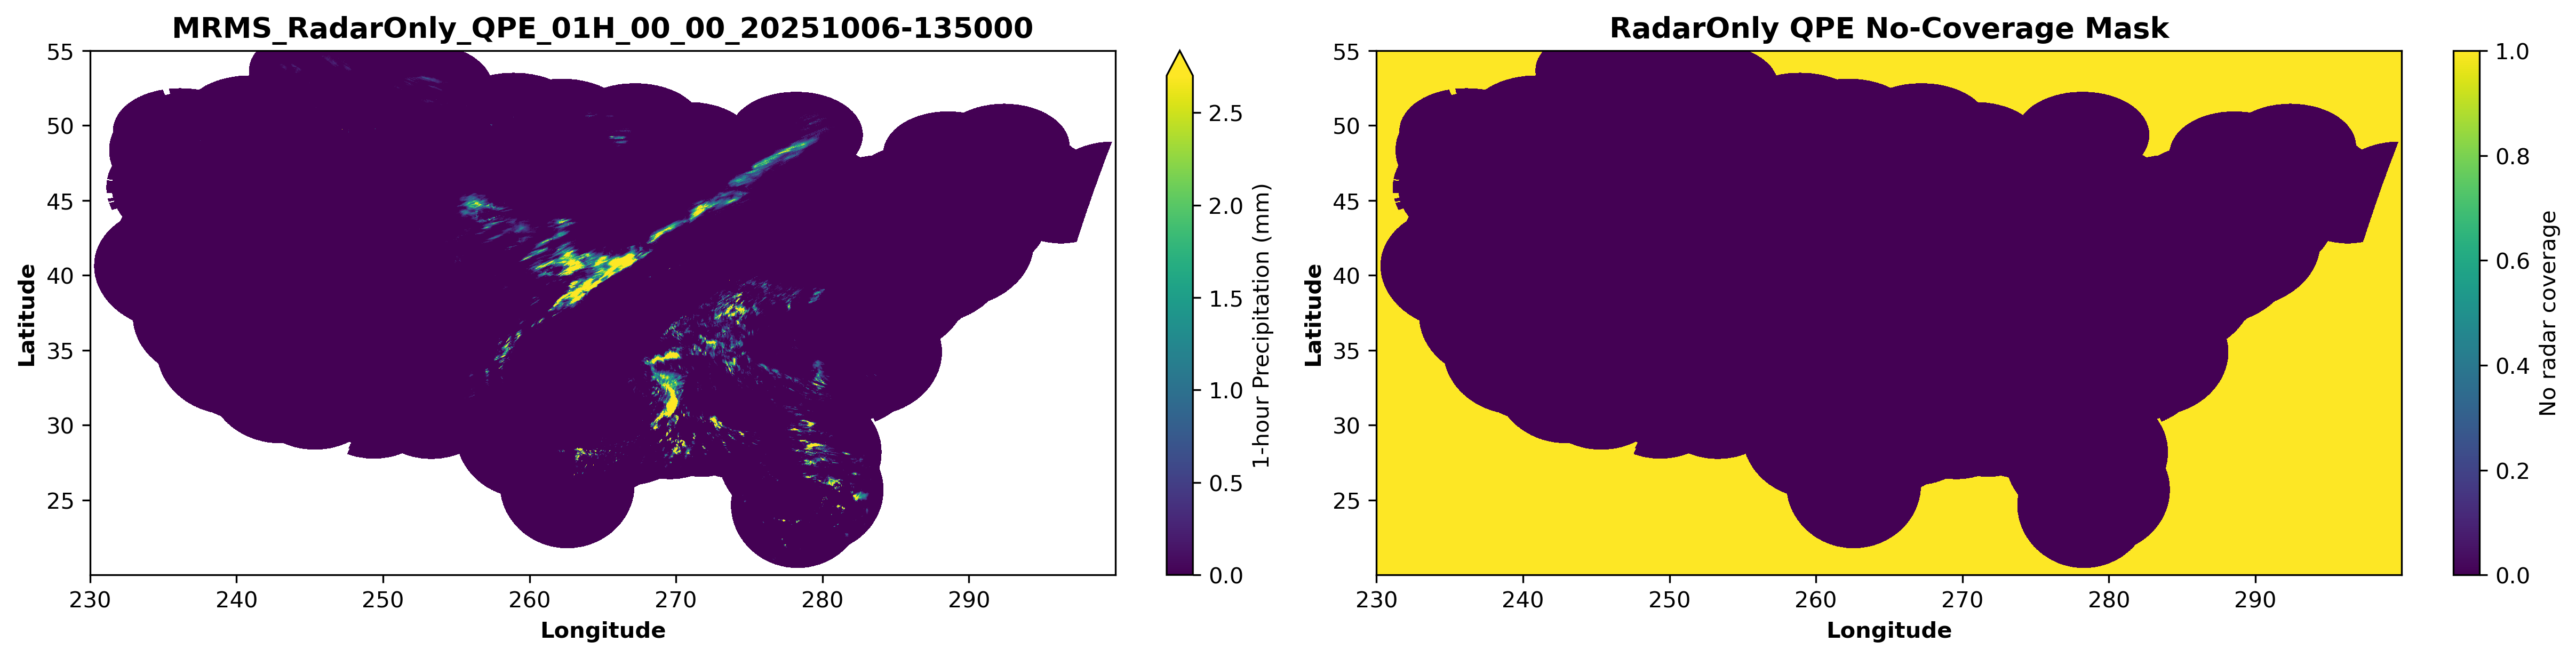

In [11]:

# we will visualize the both data and no coverage mask side by side
# seleting a random file
sample_path = random.choice(grib_files)
with xr.open_dataset(sample_path, engine="cfgrib") as ds:
    da = ds[list(ds.data_vars)[0]]  # grab 'unknown'

    # mask no-radar-coverage sentinel
    precip = da.where(da != -3)

    # no-coverage mask
    no_coverage = da == -3

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), dpi=300, constrained_layout=True)

    # first - left side precipitation
    precip.plot(
        ax=axes[0],
        x="longitude",
        y="latitude",
        vmin=0,
        vmax=np.nanpercentile(precip.values, 99.5),
        cbar_kwargs={"label": "1-hour Precipitation (mm)"}
        )

    axes[0].set_title("_".join(sample_path.name.split(".")[:-1]), fontweight="bold", fontsize=13)
    axes[0].set_xlabel("Longitude", fontweight="bold")
    axes[0].set_ylabel("Latitude", fontweight="bold")

    # right side - no-coverage mask
    no_coverage.plot(
        ax=axes[1],
        x="longitude",
        y="latitude",
        cbar_kwargs={"label": "No radar coverage"}
        )

    axes[1].set_title("RadarOnly QPE No-Coverage Mask", fontweight="bold", fontsize=13 )
    axes[1].set_xlabel("Longitude", fontweight="bold")
    axes[1].set_ylabel("Latitude", fontweight="bold")

    plt.show()
    

In [12]:

# now lets visualize all five samples - first a common v-max since common v-min will be 0
all_valid_values = []

for path in grib_files:

    with xr.open_dataset(path, engine="cfgrib") as ds_i:
        da = ds_i[list(ds_i.data_vars)[0]]

        values = da.values
        valid = values[values >= 0]

        all_valid_values.append(valid)

common_vmax = np.percentile(np.concatenate(all_valid_values), 99.9) # if you see earlier table we also have large values, those might be outliers
print(f"Common vmax: {common_vmax:.2f} mm")


Common vmax: 7.30 mm


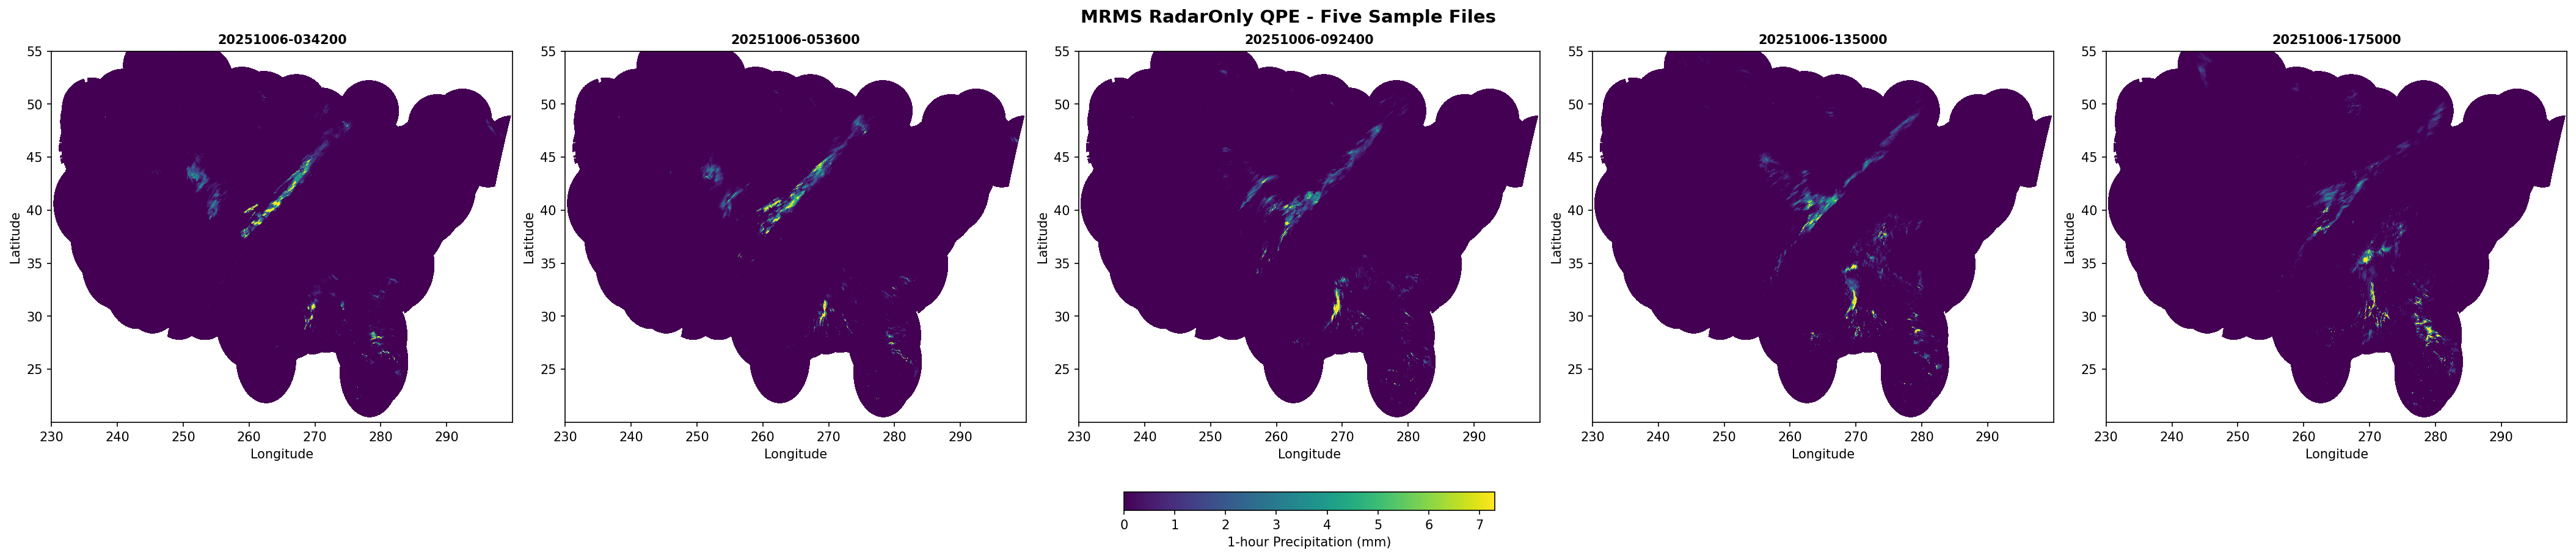

In [13]:

# now visualization
fig, axes = plt.subplots(1, len(grib_files), figsize=(28, 6), dpi=150, constrained_layout=True)

for ax, path in zip(axes, grib_files):

    with xr.open_dataset(path, engine="cfgrib") as ds_i:
        da = ds_i[list(ds_i.data_vars)[0]]
        precip = da.where(da != -3)

        im = precip.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            vmin=0,
            vmax=common_vmax,
            add_colorbar=False
            )

        timestamp = path.stem.split("_")[-1]

        ax.set_title(timestamp, fontweight="bold", fontsize=10)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05,
                    pad=0.08, label="1-hour Precipitation (mm)")

plt.suptitle("MRMS RadarOnly QPE - Five Sample Files", fontweight="bold", fontsize=14)
plt.show()


>The five sampled RadarOnly QPE fields show spatially coherent precipitation patterns that change through the day, while the overall radar-coverage footprint remains consistent. Most of the CONUS domain has little or no precipitation during these sampled hours, with localized areas of higher accumulation.
The common color scale allows direct comparison among samples and shows that precipitation intensity and spatial distribution vary substantially between timestamps.

### **Temporal Inspection**

Here we will check consecutive `RadarOnly_QPE_01H` files at the expected **2-minute interval** and see if their precipitation fields change gradually through time. Since each file represents a **rolling 1-hour accumulation**, so consecutive files should be highly similar because most of their accumulation windows overlap. Large variations are unexpcted and if exist will indicate missing files, timing issues, or data-quality problems.


In [14]:

# select 4 consecutive files around the middle of the day
mid_idx = len(files) // 2
temporal_files = files[mid_idx:mid_idx + 4]

# lets download these files and extract them
for key in temporal_files:

    gz_path = temporal_compress_path / Path(key).name

    s3.download_file(bucket, key, str(gz_path))

    grib_path = temporal_extraction_path / gz_path.name.replace(".gz", "")

    with gzip.open(gz_path, "rb") as f_in:
        with open(grib_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)

    print(f"Created: {grib_path.name}")



Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-115800.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-120000.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-120200.grib2
Created: MRMS_RadarOnly_QPE_01H_00.00_20251006-120400.grib2


In [15]:

# inspecting file times
temporal_gribs = sorted(temporal_extraction_path.glob("*.grib2"))

temporal_summary = []

for path in temporal_gribs:

    with xr.open_dataset(path, engine="cfgrib") as ds_i:

        temporal_summary.append({
            "file": path.name,
            "time": ds_i["time"].values if "time" in ds_i.coords else None,
            "step": ds_i["step"].values if "step" in ds_i.coords else None,
            "valid_time": ds_i["valid_time"].values if "valid_time" in ds_i.coords else None
            })

temporal_df = pd.DataFrame(temporal_summary)
temporal_df


,file,time,step,valid_time
0,MRMS_RadarOnly_QPE_01H_00.00_20251006-115800.g...,2025-10-06 11:58:00,0 days,2025-10-06 11:58:00
1,MRMS_RadarOnly_QPE_01H_00.00_20251006-120000.g...,2025-10-06 12:00:00,0 days,2025-10-06 12:00:00
2,MRMS_RadarOnly_QPE_01H_00.00_20251006-120200.g...,2025-10-06 12:02:00,0 days,2025-10-06 12:02:00
3,MRMS_RadarOnly_QPE_01H_00.00_20251006-120400.g...,2025-10-06 12:04:00,0 days,2025-10-06 12:04:00


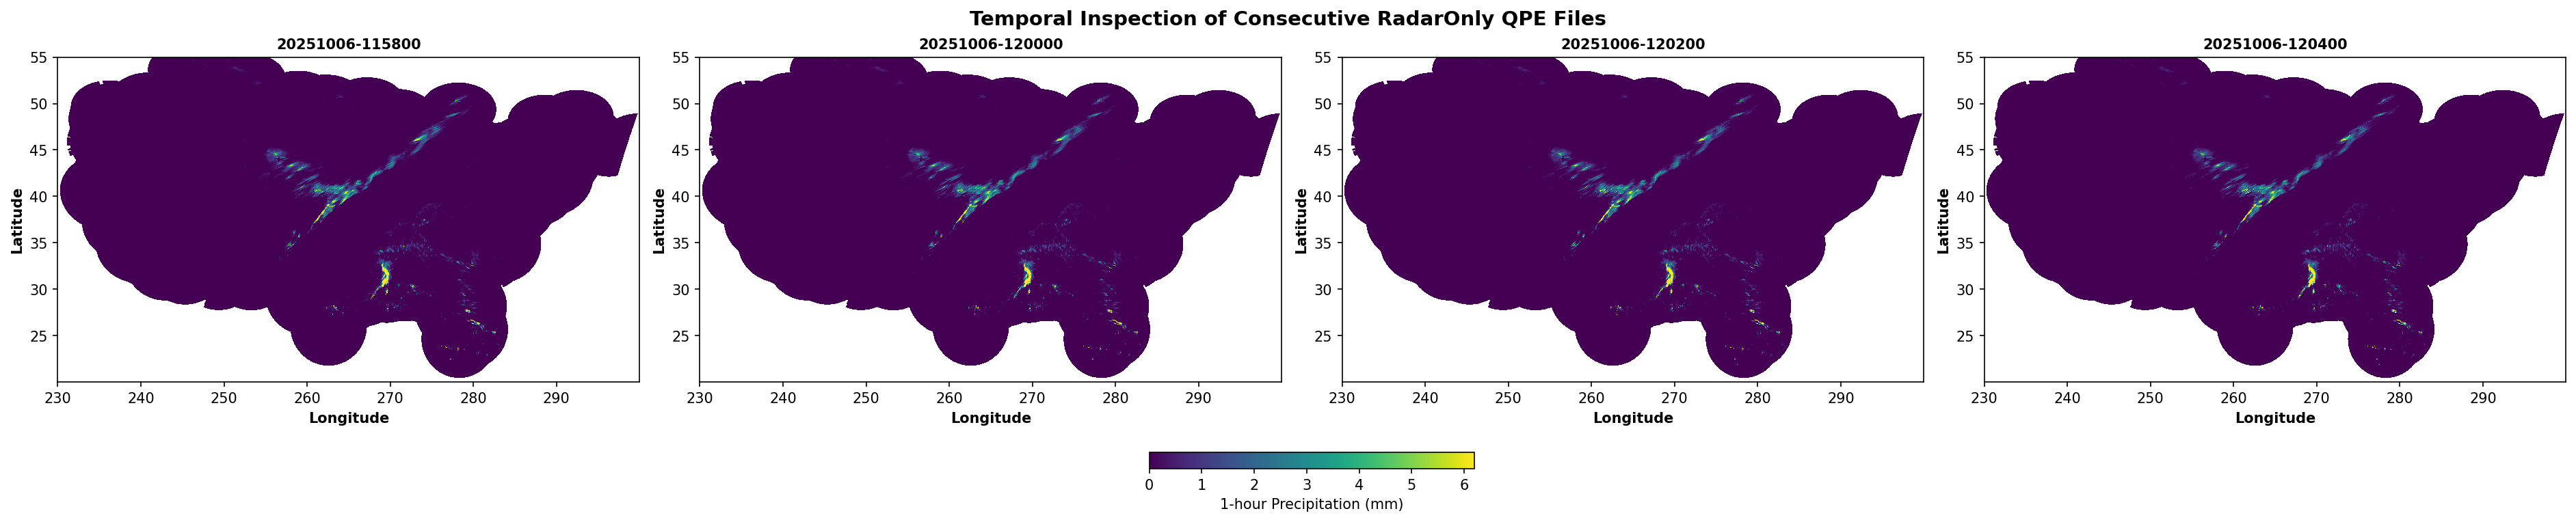

In [16]:

# visualize those fields - first get comon v-max value. 

all_valid = []
for path in temporal_gribs:
    with xr.open_dataset(path, engine="cfgrib") as ds_i:
        da = ds_i[list(ds_i.data_vars)[0]]
        values = da.values
        all_valid.append(values[values >= 0])

common_vmax = np.percentile(np.concatenate(all_valid), 99.9)

fig, axes = plt.subplots( 1, len(temporal_gribs), figsize=(25, 5), dpi=150, constrained_layout=True)
for ax, path in zip(axes, temporal_gribs):

    with xr.open_dataset(path, engine="cfgrib") as ds_i:

        da = ds_i[list(ds_i.data_vars)[0]]
        precip = da.where(da != -3)

        im = precip.plot(
            ax=ax,
            x="longitude",
            y="latitude",
            vmin=0,
            vmax=common_vmax,
            add_colorbar=False
            )

        timestamp = path.stem.split("_")[-1]

        ax.set_title(timestamp, fontweight="bold", fontsize=10)
        ax.set_xlabel("Longitude", fontweight='bold')
        ax.set_ylabel("Latitude", fontweight='bold')

fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08,
    label="1-hour Precipitation (mm)"
    )

plt.suptitle("Temporal Inspection of Consecutive RadarOnly QPE Files", fontweight="bold", fontsize=14)
plt.show()


>If we see the timing, the four consecutive files represents time: **11:58, 12:00, 12:02, and 12:04**. We can see that they have almost similar spatial precipitation patterns, with only small changes in intensity and structure between each 2-minute update.
This is consistent with the expected behavior of `RadarOnly_QPE_01H`: each file represents a **rolling 1-hour accumulation**, so consecutive fields strongly overlap in time and should evolve gradually rather than change abruptly.

### **Conclusion**


We studied the basic characteristics and behavior of the MRMS `RadarOnly_QPE_01H` product and we learned:

- It provides **radar-derived 1-hour precipitation accumulation** in **mm** on an approximately **1 km grid**.
- A new field is generated about every **2 minutes**, producing strongly overlapping rolling 1-hour accumulations.
- The sampled GRIB2 files use a `3500 × 7000` regular latitude/longitude grid.
- `cfgrib/ecCodes` decodes the precipitation array but labels the MRMS-specific variable metadata as `unknown`.
- The only negative value observed in the samples was **`-3`**, representing **no radar coverage**; no `-1` missing-value pixels were observed.
- Sentinel values must therefore be masked before computing precipitation statistics or using the data downstream.
- Visual and temporal inspection showed spatially coherent precipitation patterns and gradual changes between consecutive 2-minute updates, consistent with the expected rolling-accumulation behavior.




# References

**[1] NOAA — MRMS Dataset, Registry of Open Data on AWS**
Provides the official MRMS overview, operational history, two-minute update cycle, v11→v12 transition, and public AWS access information.
https://registry.opendata.aws/noaa-mrms-pds/

**[2] NOAA Warning Decision Training Division — Surface Precipitation Rate (SPR)**
Describes SPR, its approximately 1-km spatial resolution, two-minute temporal resolution, and its use in constructing one-hour RadarOnly QPE accumulations.
https://vlab.noaa.gov/web/wdtd/-/surface-precipitation-rate-spr-1

**[3] NOAA Warning Decision Training Division — Seamless Hybrid Scan Reflectivity (SHSR)**
Describes the quality-controlled low-level reflectivity field used as an input to Surface Precipitation Rate and its relationship with radar blockage information.
https://vlab.noaa.gov/web/wdtd/-/seamless-hybrid-scan-reflectivity-shsr-

**[4] NOAA Warning Decision Training Division — Surface Precipitation Type (SPT)**
Describes precipitation-type classification and its role in selecting radar precipitation relationships for Surface Precipitation Rate.
https://vlab.noaa.gov/web/wdtd/-/surface-precipitation-type-spt-

**[5] NOAA/NSSL — Operational MRMS GRIB2 Product Tables**
Official product table listing `RadarOnly_QPE_01H`, its one-hour accumulation period, two-minute update interval, units (`mm`), and MRMS GRIB2 metadata/special codes.
https://www.nssl.noaa.gov/projects/mrms/operational/tables.php

**[6] NOAA Warning Decision Training Division — QPE: Radar Only**
Official training/documentation page describing the MRMS RadarOnly precipitation accumulation product and its characteristics.
https://vlab.noaa.gov/web/wdtd/-/qpe-radar-only

**[7] NOAA/NSSL — Timeline of MRMS Builds**
Documents the October 2020 MRMS v12 transition and major QPE-related changes, including updates to RadarOnly QPE and introduction of RAQI.
https://inside.nssl.noaa.gov/mrms/build_timeline/

**[8] NOAA/NSSL — Multi-Radar/Multi-Sensor System**
General official MRMS system overview and documentation entry point.
https://www.nssl.noaa.gov/projects/mrms/

**[9] NOAA MRMS Public AWS Archive**
Primary source from which the raw MRMS files used in this notebook will be downloaded.
https://noaa-mrms-pds.s3.amazonaws.com/index.html
